In [1]:
import pickle


data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples
unlabeled_samples = all_data[126:]

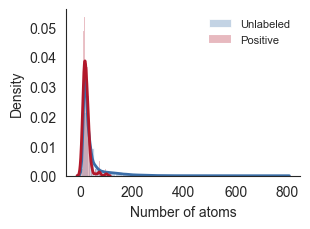

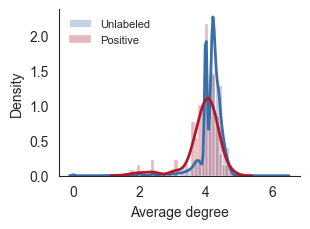

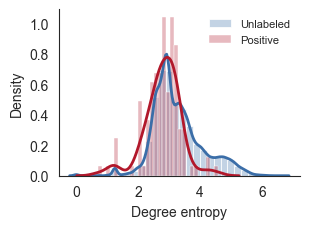

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Extract graph properties
# ==========================
def get_properties(dataset):
    atoms = []
    avg_degree = []
    degree_entropy = []

    for data in dataset:

        n = data.n_nodes
        e = data.n_edges

        # Number of atoms
        atoms.append(n)

        # Average degree
        deg = 2 * e / n
        avg_degree.append(deg)

        # Degree entropy
        row = data.edge_index[0].cpu().numpy()
        degrees = np.bincount(row, minlength=n)

        p = degrees / (degrees.sum() + 1e-12)
        entropy = -(p * np.log(p + 1e-12)).sum()

        degree_entropy.append(entropy)

    return (
        np.array(atoms),
        np.array(avg_degree),
        np.array(degree_entropy)
    )


atoms_pos, degree_pos, entropy_pos = get_properties(positive_samples)
atoms_un, degree_un, entropy_un = get_properties(unlabeled_samples)

# ==========================
# Global style
# ==========================
plt.rcParams["font.family"] = "Arial"
sns.set_style("white")

positive_color = "#B2182B"
unlabeled_color = "#3B6EA8"


# ==========================
# Plot function
# ==========================
def plot_distribution(
        x1,
        x2,
        xlabel,
        save_name):

    plt.figure(figsize=(3.2, 2.4))

    sns.histplot(
        x2,
        bins=30,
        stat='density',
        alpha=0.3,
        color=unlabeled_color,
        label='Unlabeled'
    )

    sns.histplot(
        x1,
        bins=30,
        stat='density',
        alpha=0.3,
        color=positive_color,
        label='Positive'
    )

    sns.kdeplot(
        x2,
        color=unlabeled_color,
        linewidth=2
    )

    sns.kdeplot(
        x1,
        color=positive_color,
        linewidth=2
    )

    plt.xlabel(xlabel)
    plt.ylabel("Density")

    plt.legend(
        frameon=False,
        fontsize=8
    )

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        save_name,
        dpi=600,
        transparent=True,
        bbox_inches='tight'
    )

    plt.show()


# ==========================
# Figure S2a
# Number of atoms
# ==========================
plot_distribution(
    atoms_pos,
    atoms_un,
    "Number of atoms",
    "atoms_distribution.svg"
)


# ==========================
# Figure S2b
# Average degree
# ==========================
plot_distribution(
    degree_pos,
    degree_un,
    "Average degree",
    "average_degree_distribution.svg"
)


# ==========================
# Figure S2c
# Degree entropy
# ==========================
plot_distribution(
    entropy_pos,
    entropy_un,
    "Degree entropy",
    "degree_entropy_distribution.svg"
)